## DL4M-FINAL_Group 8<br>
### Dataset Processing Part<br>
Yuantao Li

---

As the project proposal said, our goal is to develop a instrument classification model in noisy conditions. To get ready for the model training, I am responsible for creating the training dataset. In the team discussion, we all agreed that combining existing datasets is the most feasible approach. 

After searching and comparing, I chose IRMAS and Musan as the basis for synthesizing a new dataset. IRMAS is a dataset that intended to be used for training and testing methods for the automatic recognition of predominant instruments in musical audio, which is similar to our goal. There are 11 instruments contained: cello, clarinet, flute, acoustic guitar, electric guitar, organ, piano, saxophone, trumpet, violin, and human singing voice. There are 6705 audio files in 16 bit stereo wav format sampled at 44.1kHz. The number of files per instrument are: cel(388), cla(505), flu(451), gac(637), gel(760), org(682), pia(721), sax(626), tru(577), vio(580), voi(778). Musan is a dataset for music/speech discrimination, speech/nonspeech detection, and voice activity detection. Musan is divided into music, speech, and noise portions. For the dataset creation, I only used noise portions. The noise portion contains 843 a wide variety of technical and non-technical noises that cannot be considered speech or music. 

The data processing process of this notebook is divided into two parts. The first part is the test content, the main purpose of which is to test whether the audio can be imported, merged and output normally. The second part is the program responsible for batch export, which batch merges and exports the audio in the data set according to the merging function in the first part and the set SNR. In order to improve the efficiency of generation and model training, I adjusted the audio sampling rate to 16000Hz when importing.

---

#### 1: Data Test

In [1]:
import os
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

In [2]:
'''
irmas_path = '/Volumes/TOSHIBA EXT/DL4M_Final Dataset/IRMAS'
musan_path = '/Volumes/TOSHIBA EXT/DL4M_Final Dataset/musan'
'''
irmas_sample_path = '/Volumes/TOSHIBA EXT/DL4M_Final Dataset/IRMAS/IRMAS-TrainingData/cel/[cel][cla]0015__1.wav'
musan_sample_path = '/Volumes/TOSHIBA EXT/DL4M_Final Dataset/musan/noise/free-sound/noise-free-sound-0001.wav'
# Load the test audio files

File: /Volumes/TOSHIBA EXT/DL4M_Final Dataset/IRMAS/IRMAS-TrainingData/cel/[cel][cla]0015__1.wav, Sample Rate: 16000, Duration: 3.00 seconds
File: /Volumes/TOSHIBA EXT/DL4M_Final Dataset/musan/noise/free-sound/noise-free-sound-0001.wav, Sample Rate: 16000, Duration: 40.54 seconds


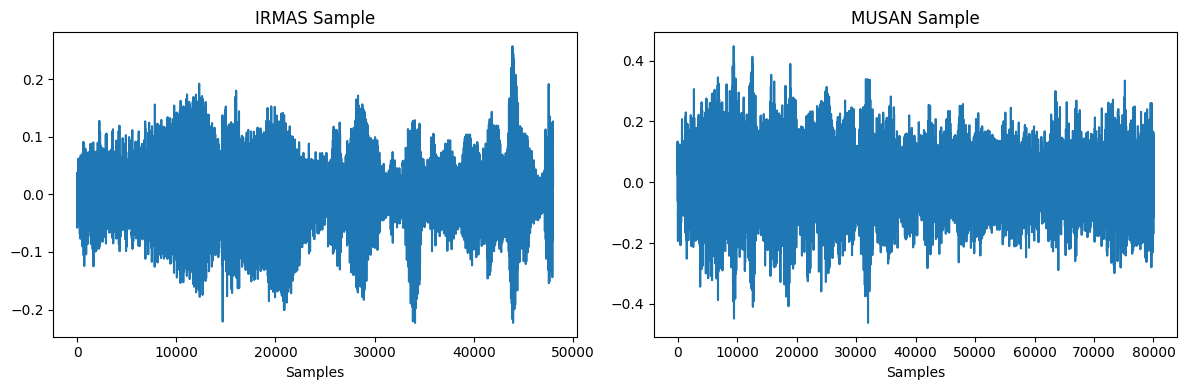

In [3]:
irmas_sample_audio, irmas_sample_sr = librosa.load(irmas_sample_path, sr=16000)
musan_sample_audio, musan_sample_sr = librosa.load(musan_sample_path, sr=None)
# Use librosa to load the audio files and change the sample rate of IRMAS to 16000 Hz

print(f"File: {irmas_sample_path}, Sample Rate: {irmas_sample_sr}, Duration: {len(irmas_sample_audio) / irmas_sample_sr:.2f} seconds")
print(f"File: {musan_sample_path}, Sample Rate: {musan_sample_sr}, Duration: {len(musan_sample_audio) / musan_sample_sr:.2f} seconds")
# Print the sample rate and duration

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("IRMAS Sample")
plt.plot(irmas_sample_audio[:irmas_sample_sr * 5]) 
plt.xlabel("Samples")

plt.subplot(1, 2, 2)
plt.title("MUSAN Sample")
plt.plot(musan_sample_audio[:musan_sample_sr * 5])
plt.xlabel("Samples")

plt.tight_layout()
plt.show()
# Show the first 5 seconds of each audio sample

The Process of mix signal and noise in the specific SNR value:

1: Calculate the power of signal and noise: $P_x = \frac{1}{N} \sum_{n=1}^{N} x[n]^2$

2: Get the noise power in the specific SNR value: $\text{SNR} = 10 \log_{10} \left( \frac{P_{\text{signal}}}{P_{\text{noise}}} \right)$

3: Scale the power of noise to the target value.

In [4]:
def snr_noise(signal, noise, snr_db):
    '''
    This function mixes a signal with noise at a specified SNR (Signal-to-Noise Ratio) in dB.
    
    Inputs:
    - signal: The original audio signal (type: numpy array)
    - noise: The noise signal to be mixed (type: numpy array)
    - snr_db: Desired SNR in decibels (type: float)

    Outputs:
    - mixed_signal: The resulting audio signal after mixing (type: numpy array)
    '''
    if len(noise) < len(signal):
        raise ValueError("Noise must be at least as long as the signal.")
    #Check if noise is longer than the signal

    noise = noise[:len(signal)]
    #Trim noise to the length of the signal

    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    #Calculate the power of the signal and noise

    noise_power_target = signal_power / (10**(snr_db / 10))
    noise_scaling_factor = np.sqrt(noise_power_target / noise_power)
    noise_scaled = noise * noise_scaling_factor
    # Calculate the scaling factor for the noise to get the desired SNR, then scale the noise
    
    mixed_signal = signal + noise_scaled
    return mixed_signal

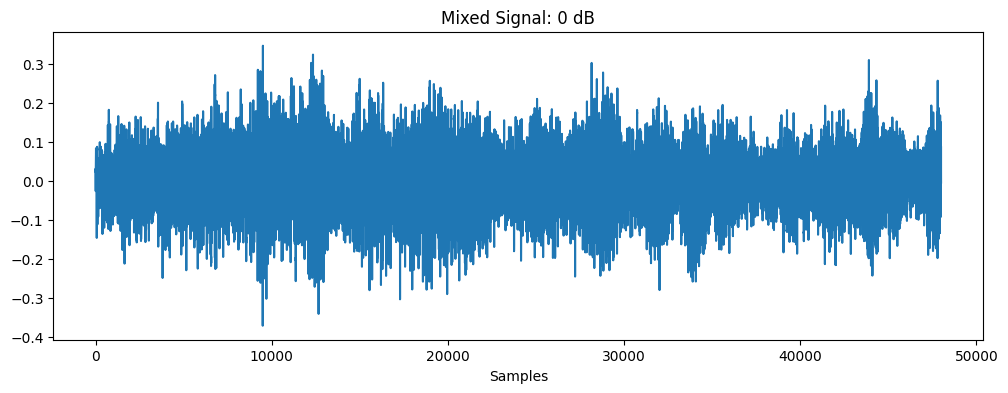

In [5]:
duration = 3  # seconds
length = duration * irmas_sample_sr
snr_signal_sample = irmas_sample_audio[:length]
snr_noise_sample = musan_sample_audio[:length]
# Select the first 3 seconds of each test audio slices for mixing

snr_db = 0 # Choose the desired SNR in dB here
snr_mixed_audio = snr_noise(snr_signal_sample, snr_noise_sample, snr_db)

plt.figure(figsize=(12, 4))
plt.title(f"Mixed Signal: {snr_db} dB")
plt.plot(snr_mixed_audio)
plt.xlabel("Samples")
plt.show()
# Show the mixed audio

In [6]:
sf.write('snr_mixed_audio_test.wav', snr_mixed_audio, irmas_sample_sr)
# Save the test audio

---

#### 2: Batch Output

In [7]:
import random
from tqdm import tqdm
from pathlib import Path

In [8]:
irmas_batch_root = "/Volumes/TOSHIBA EXT/DL4M_Final Dataset/IRMAS/IRMAS-TrainingData"
musan_batch_root = "/Volumes/TOSHIBA EXT/DL4M_Final Dataset/musan/noise/free-sound"
output_root = "/Users/lyt-48vpower/Documents/DL4M/Final/Output_Dataset/Ver1/SNR10"
# Set the paths for the datasets and output directory

batch_snr_db = 10 # Choose the desired SNR in dB here
batch_target_sr = 16000

In [9]:
def batch_snr_noise(signal, noise, snr_db):
    '''
    This function is same as the previous one (snr_noise).
    '''
    if len(noise) < len(signal):
        raise ValueError("Noise must be at least as long as the signal.")
    
    noise = noise[:len(signal)]

    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    
    noise_power_target = signal_power / (10**(snr_db / 10))
    
    noise_scaling_factor = np.sqrt(noise_power_target / noise_power)
    noise_scaled = noise * noise_scaling_factor
    
    mixed_signal = signal + noise_scaled
    return mixed_signal

In [10]:
def get_valid_audio_paths(root_dir, pattern="*.wav", sr=16000, max_files=None):
    """
    Scan all audio files matching pattern under root_dir and try to read them using librosa.
    Successfully read paths will be returned, and failed files will be automatically skipped.

    Inputs:
    - root_dir: The root directory to scan for audio files (type: str or Path)
    - pattern: The pattern of audio files (type: str, default: "*.wav")
    - sr: The sample rate to use when loading audio files (type: int, default: 16000)
    - max_files: The maximum number of files to process (type: int, default: None)

    Outputs:
    - valid_paths: A list of paths to successfully loaded valid audio files (type: list --> Path)
    """
    root = Path(root_dir)
    audio_paths = [p for p in root.rglob(pattern) if not p.name.startswith("._")]
    valid_paths = []
    # Set the root directory and audio paths, remove MacOS hidden '._' files, and initialize valid paths list

    print(f"Checking {len(audio_paths)} audio files...")

    for i, path in enumerate(audio_paths):
        try:
            librosa.load(str(path), sr=sr)
            valid_paths.append(path)
        except Exception as e:
            print(f"Can not load {path.name} because of {e}")
        # Use try-except to load each audio file and print the error if it fails

        if max_files and len(valid_paths) >= max_files:
            break
        # Stop processing if the max number of files reached

    print(f"Loaded {len(valid_paths)} valid audio files.")
    return valid_paths

In [11]:
os.makedirs(output_root, exist_ok=True)
instrument_folders = [f for f in os.listdir(irmas_batch_root) if not f.startswith("._") and os.path.isdir(os.path.join(irmas_batch_root, f))]
# Make sure the output directory exists, get the list of instrument folders in the IRMAS dataset, remove MacOS hidden '._' files

musan_batch_files = get_valid_audio_paths(musan_batch_root)
# Get valid audio paths from the MUSAN dataset

for instr in instrument_folders:
    instr_path = os.path.join(irmas_batch_root, instr)
    output_instr_path = os.path.join(output_root, instr)
    os.makedirs(output_instr_path, exist_ok=True)
    # Create output directory for each instrument

    for file in tqdm(os.listdir(instr_path), desc=f"Processing {instr}"):
        # Show progress with tqdm

        if file.startswith("._") or not file.endswith(".wav"):
            continue
        # Skip MacOS hidden '._' files and non-wav files

        irmas_path = os.path.join(instr_path, file)
        try:
            irmas_audio, _ = librosa.load(irmas_path, sr=batch_target_sr)
        except:
            print(f"Instr Reading Failed: {irmas_path}")
            continue
        # Also use try-except to load each IRMAS audio file and print error

        noise_path = random.choice(musan_batch_files)
        try:
            musan_audio, _ = librosa.load(noise_path, sr=batch_target_sr)
        except:
            print(f"Noise Reading Failed: {noise_path}")
            continue
        # Randomly select a noise file from the MUSAN dataset and load it, also using try-except

        if len(musan_audio) < len(irmas_audio):
            continue  
        # Make sure the noise is at least as long as the signal

        mixed_audio = batch_snr_noise(irmas_audio, musan_audio, batch_snr_db)
        # Mix it

        output_file = file.replace(".wav", f"_snr{batch_snr_db}.wav")
        output_path = os.path.join(output_instr_path, output_file)
        sf.write(output_path, mixed_audio, batch_target_sr)
        # Save the mixed audio to the output directory

Checking 843 audio files...
Loaded 843 valid audio files.


Processing cel: 100%|██████████| 776/776 [00:04<00:00, 181.89it/s]
